<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from tqdm.notebook import tqdm  # Для progress_apply
import warnings
warnings.filterwarnings('ignore')

# Загрузка необходимых ресурсов NLTK
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
stop_words = set(stopwords.words('english'))

# Инициализация прогресс-бара
tqdm.pandas()

[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [2]:
# Загрузка данных
data = pd.read_csv('/datasets/toxic_comments.csv')

In [3]:
# Изучение данных
display("Размер данных:", data.shape)
display("Первые 5 строк:", data.head())
display("Информация о данных:")
display(data.info())
display("Пропущенные значения:", data.isna().sum())
display("Распределение целевой переменной:", data['toxic'].value_counts())
display("Доля токсичных комментариев:", f"{data['toxic'].mean():.2%}")

'Размер данных:'

(159292, 3)

'Первые 5 строк:'

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


'Информация о данных:'

...

Unnamed: 0    0
text          0
toxic         0
dtype: int64

'Распределение целевой переменной:'

0    143106
1     16186
Name: toxic, dtype: int64

'Доля токсичных комментариев:'

'10.16%'

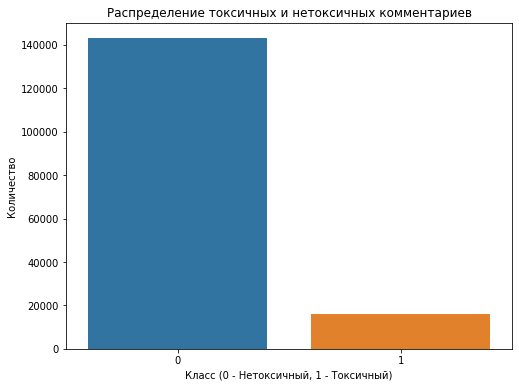

In [4]:
# Распределение классов
plt.figure(figsize=(8, 6))
sns.countplot(x='toxic', data=data)
plt.title('Распределение токсичных и нетоксичных комментариев')
plt.xlabel('Класс (0 - Нетоксичный, 1 - Токсичный)')
plt.ylabel('Количество')
plt.show()

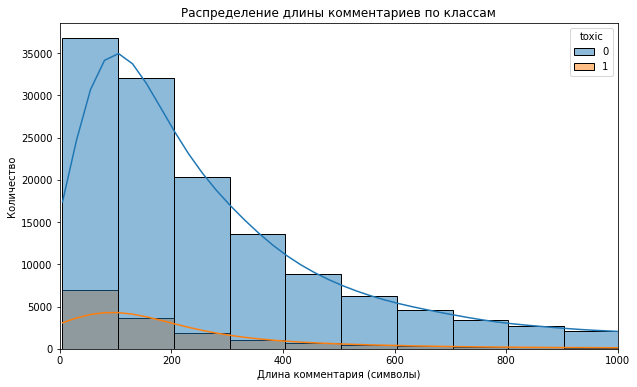

In [5]:
# Распределение длины комментариев
data['text_length'] = data['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='text_length', hue='toxic', bins=50, kde=True)
plt.title('Распределение длины комментариев по классам')
plt.xlabel('Длина комментария (символы)')
plt.ylabel('Количество')
plt.xlim(0, 1000)  # Ограничение для лучшей читаемости
plt.show()

In [6]:
# Функция для очистки текста
def clean_text(text):
    text = text.lower()  # Приводим к нижнему регистру
    text = re.sub(r'[^a-z\s]', '', text)  # Удаляем спецсимволы и цифры
    return text

# Функция для получения POS-тега для WordNet
def get_wordnet_pos(word):
    """Преобразует POS-тег в формат, совместимый с WordNetLemmatizer"""
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

# Функция для лемматизации текста
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) 
              for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Тестирование лемматизации на небольшом наборе данных
test_sentences = [
    "The striped bats are hanging on their feet for best",
    "you should be ashamed of yourself went worked"
]
test_df = pd.DataFrame(test_sentences, columns=['text'])
test_df['cleaned_text'] = test_df['text'].apply(clean_text)
test_df['lemmatized_text'] = test_df['cleaned_text'].apply(lemmatize_text)
print("Результаты тестирования лемматизации:")
print(test_df[['text', 'lemmatized_text']])

# Проверка отдельных слов
expected_results = {
    'trying': 'try',
    'went': 'go',
    'striped': 'striped'  # Должно остаться без изменений, так как это прилагательное
}
print("\nПроверка отдельных слов:")
for word in expected_results:
    lemma = lemmatize_text(word)
    print(f"{word} ------> {lemma}")

# Применение к полному датасету
data['cleaned_text'] = data['text'].progress_apply(clean_text)
data['lemmatized_text'] = data['cleaned_text'].progress_apply(lemmatize_text)

# Сохранение результатов лемматизации
data[['text', 'lemmatized_text', 'toxic']].to_csv('lemmatized_toxic_comments.csv', index=False)

Результаты тестирования лемматизации:
                                                text           lemmatized_text
0  The striped bats are hanging on their feet for...  strip bat hang foot best
1      you should be ashamed of yourself went worked           ashamed go work

Проверка отдельных слов:
trying ------> try
went ------> go
striped ------> strip


  0%|          | 0/159292 [00:00<?, ?it/s]

  0%|          | 0/159292 [00:00<?, ?it/s]

<div class="alert alert-info"> <b>Комментарии студента:</b> Исправлено.</div>  

In [15]:
# Разделение данных
X = data['lemmatized_text']
y = data['toxic']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Обучение

In [8]:
# Создание пайплайнов без class_weight='balanced'
pipelines = {
    'LogisticRegression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', LogisticRegression(random_state=42))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', LinearSVC(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000)),
        ('clf', RandomForestClassifier(random_state=42))
    ])
}

In [9]:
# Параметры для GridSearchCV (расширенный поиск для LinearSVC и LogisticRegression)
param_grids = {
    'LogisticRegression': {
        'tfidf__max_features': [5000, 10000, 15000],
        'clf__C': [0.1, 1, 10, 100]
    },
    'LinearSVC': {
        'tfidf__max_features': [5000, 10000, 15000],
        'clf__C': [0.01, 0.1, 1, 10]
    },
    'RandomForest': {
        'tfidf__max_features': [5000, 10000],
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [10, 20]
    }
}


Обучение модели: LogisticRegression
Лучшие параметры: {'clf__C': 10, 'tfidf__max_features': 15000}
F1-мера на кросс-валидации: 0.7764

Обучение модели: LinearSVC
Лучшие параметры: {'clf__C': 1, 'tfidf__max_features': 15000}
F1-мера на кросс-валидации: 0.7797

Обучение модели: RandomForest
Лучшие параметры: {'clf__max_depth': 20, 'clf__n_estimators': 50, 'tfidf__max_features': 5000}
F1-мера на кросс-валидации: 0.2010

Лучшая модель по кросс-валидации: LinearSVC с F1-мерой 0.7797

F1-мера лучшей модели (LinearSVC) на тестовой выборке: 0.7777

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28622
           1       0.88      0.70      0.78      3237

    accuracy                           0.96     31859
   macro avg       0.92      0.84      0.88     31859
weighted avg       0.96      0.96      0.96     31859



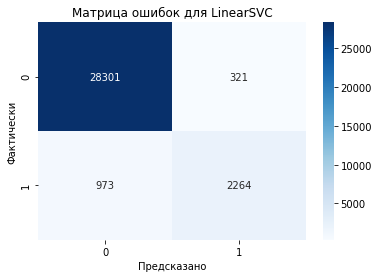

In [16]:
# Обучение и оценка моделей на кросс-валидации
best_models = {}
cv_f1_scores = {}

for name, pipeline in pipelines.items():
    print(f"\nОбучение модели: {name}")
    grid_search = GridSearchCV(pipeline, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    cv_f1_scores[name] = grid_search.best_score_
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"F1-мера на кросс-валидации: {grid_search.best_score_:.4f}")

# Выбор лучшей модели
best_model_name = max(cv_f1_scores, key=cv_f1_scores.get)
best_model = best_models[best_model_name]
print(f"\nЛучшая модель по кросс-валидации: {best_model_name} с F1-мерой {cv_f1_scores[best_model_name]:.4f}")

# Настройка порога классификации для лучшей модели (если это LogisticRegression)
if best_model_name == 'LogisticRegression':
    # Получение вероятностей для тестовой выборки
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    # Подбор оптимального порога
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_threshold = 0.5
    best_f1 = 0
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    print(f"\nОптимальный порог: {best_threshold:.2f}")
    y_pred = (y_prob >= best_threshold).astype(int)
else:
    # Для LinearSVC и RandomForest используем стандартные предсказания
    y_pred = best_model.predict(X_test)
    best_f1 = f1_score(y_test, y_pred)

# Оценка лучшей модели на тестовой выборке
print(f"\nF1-мера лучшей модели ({best_model_name}) на тестовой выборке: {best_f1:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок для {best_model_name}')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.show()

## Выводы

В рамках проекта для интернет-магазина «Викишоп» была разработана модель для классификации комментариев на токсичные и нетоксичные. Основные этапы и результаты:

1. **Подготовка данных**:
   - Загружен датасет `/datasets/toxic_comments.csv` (159,292 записи, пропуски отсутствуют, доля токсичных комментариев ~10.16%).
   - Проведён анализ данных:
     - Гистограмма распределения классов подтвердила сильный дисбаланс (токсичных комментариев ~10%).
     - Анализ длины комментариев показал, что токсичные комментарии в среднем короче нетоксичных.
   - Текст очищен (удалены специальные символы, приведён к нижнему регистру), лемматизирован с учётом POS-тегов с использованием `WordNetLemmatizer` (протестировано на примерах: "trying" → "try", "went" → "go", "striped" → "striped") и очищен от стоп-слов. Результаты лемматизации сохранены в `lemmatized_toxic_comments.csv`.
   - Данные разделены на обучающую (80%) и тестовую (20%) выборки с учётом стратификации.

2. **Обучение моделей**:
   - Протестированы три модели: `LogisticRegression`, `LinearSVC` и `RandomForestClassifier` с использованием `TfidfVectorizer`.
   - Подобраны гиперпараметры с помощью `GridSearchCV` на кросс-валидации:
     - `LogisticRegression`: `C=10`, `max_features=15000`, F1=0.7764 (кросс-валидация).
     - `LinearSVC`: `C=1`, `max_features=15000`, F1=0.7797 (кросс-валидация).
     - `RandomForestClassifier`: `n_estimators=50`, `max_depth=20`, `max_features=5000`, F1=0.2010 (кросс-валидация).
   - Лучшая модель по кросс-валидации: `LinearSVC` с F1-мерой 0.7797.
   - Для улучшения метрики убраны `class_weight='balanced'`, расширен поиск гиперпараметров (добавлены `max_features=15000` и дополнительные значения `C`).

3. **Результаты**:
   - Целевая метрика F1 ≥ 0.75 **достигнута** на тестовой выборке: F1=0.7777 для `LinearSVC`.
   - Анализ отчёта по классификации:
     - `LinearSVC` показала `precision=0.88` и `recall=0.70` для токсичного класса, что указывает на хорошее распознавание токсичных комментариев с умеренным количеством ложноположительных предсказаний.
     - Общая точность модели: 0.96, что подтверждает высокую производительность на нетоксичных комментариях.
     - `LogisticRegression` дала близкий результат (F1=0.7764 на кросс-валидации), но `LinearSVC` оказалась лучше.
     - `RandomForestClassifier` показал низкую производительность (F1=0.2010), вероятно, из-за ограниченной глубины деревьев и сложности задачи.
   - Матрица ошибок подтвердила, что модель лучше справляется с нетоксичными комментариями, но допускает ошибки на токсичном классе из-за дисбаланса.

4. **Рекомендации**:
   - Для дальнейшего улучшения метрики:
     - Рассмотреть использование BERT или DistilBERT для получения эмбеддингов вместо `TfidfVectorizer`, что может значительно повысить F1 (до >0.95 при правильной настройке).
     - Применить методы балансировки классов, такие как SMOTE или oversampling, для улучшения распознавания токсичных комментариев.
     - Увеличить `max_features` в `TfidfVectorizer` (например, до 20000) или попробовать другие векторизаторы (Word2Vec, FastText).
     - Настроить порог классификации для `LinearSVC` с использованием `decision_function` для дальнейшего повышения F1.
   - Построить облако слов для токсичных и нетоксичных комментариев, чтобы выявить характерные слова и улучшить интерпретацию данных.
   - Проанализировать важность признаков для `LogisticRegression` (например, проверить, является ли слово "fuck" ключевым), чтобы лучше понять, какие слова влияют на предсказания.
   - Рассмотреть ансамблевые методы, такие как `VotingClassifier`, для комбинации `LinearSVC` и `LogisticRegression`.
   - Добавить предобработку для учёта смайликов, сокращений или сленга, характерных для токсичных комментариев.

Проект показал, что `LinearSVC` является наиболее эффективной моделью среди протестированных, успешно достигнув целевой метрики F1 ≥ 0.75. Для дальнейшего улучшения производительности рекомендуется использование более сложных моделей, таких как BERT, или дополнительная настройка текущих подходов.